### **CHRISTIAN FRIOLO**
### **BCS42**
### **MODULE 10 - MARKOV DECISION MODEL**

##### **ACTIVITY 1**

In [ ]:
import numpy as np
import random

# States
states = ["S0", "S1", "S2"]

# Actions
actions = ["A", "B"]

# Transition probabilities
P = {
    "S0": {
        "A": {"S1": 0.9, "S0": 0.1},
        "B": {"S1": 1.0}
    },
    "S1": {
        "A": {"S2": 1.0},
        "B": {"S0": 1.0}
    },
    "S2": {
        "A": {"S2": 1.0},
        "B": {"S2": 1.0}
    }
}

# Reward function
R = {
    "S0": {
        "A": {"S1": +5, "S0": 0},
        "B": {"S1": +1}
    },
    "S1": {
        "A": {"S2": +10},
        "B": {"S0": -1}
    },
    "S2": {
        "A": {"S2": 0},
        "B": {"S2": 0}
    }
}

In [ ]:
def sample_next_state(state, action):
    transitions = P[state][action]
    next_states = list(transitions.keys())
    probabilities = list(transitions.values())
    return random.choices(next_states, probabilities)[0]

In [ ]:
def run_episode(max_steps=10, verbose=True):
    state = "S0"
    total_reward = 0
    steps_record = []

    if verbose:
        print("Starting at:", state)

    for step in range(max_steps):
        action = random.choice(actions)
        next_state = sample_next_state(state, action)
        reward = R[state][action][next_state]

        steps_record.append((state, action, next_state, reward))

        if verbose:
            print(f"Step {step}: State={state}, Action={action}, "
                  f"Next={next_state}, Reward={reward}")

        total_reward += reward
        state = next_state

    if verbose:
        print("Total reward collected:", total_reward)

    return total_reward, steps_record


# Try running a sample episode
run_episode()

Starting at: S0
Step 0: State=S0, Action=A, Next=S1, Reward=5
Step 1: State=S1, Action=A, Next=S2, Reward=10
Step 2: State=S2, Action=A, Next=S2, Reward=0
Step 3: State=S2, Action=A, Next=S2, Reward=0
Step 4: State=S2, Action=B, Next=S2, Reward=0
Step 5: State=S2, Action=B, Next=S2, Reward=0
Step 6: State=S2, Action=A, Next=S2, Reward=0
Step 7: State=S2, Action=A, Next=S2, Reward=0
Step 8: State=S2, Action=A, Next=S2, Reward=0
Step 9: State=S2, Action=B, Next=S2, Reward=0
Total reward collected: 15


(15,
 [('S0', 'A', 'S1', 5),
  ('S1', 'A', 'S2', 10),
  ('S2', 'A', 'S2', 0),
  ('S2', 'A', 'S2', 0),
  ('S2', 'B', 'S2', 0),
  ('S2', 'B', 'S2', 0),
  ('S2', 'A', 'S2', 0),
  ('S2', 'A', 'S2', 0),
  ('S2', 'A', 'S2', 0),
  ('S2', 'B', 'S2', 0)])

In [ ]:
def run_multiple_episodes(n=50, max_steps=10):
    episode_rewards = []

    for _ in range(n):
        total_reward, _ = run_episode(max_steps=max_steps, verbose=False)
        episode_rewards.append(total_reward)

    return episode_rewards


rewards = run_multiple_episodes(n=50, max_steps=10)
print("Rewards collected:", rewards)
print("Average reward:", np.mean(rewards))

Rewards collected: [11, 11, 15, 11, 11, 11, 15, 15, 11, 15, 11, 19, 11, 19, 11, 11, 19, 19, 11, 19, 15, 19, 15, 15, 11, 15, 11, 15, 19, 11, 15, 19, 19, 15, 15, 23, 19, 15, 8, 15, 11, 11, 11, 15, 11, 15, 11, 11, 15, 15]
Average reward: 14.22


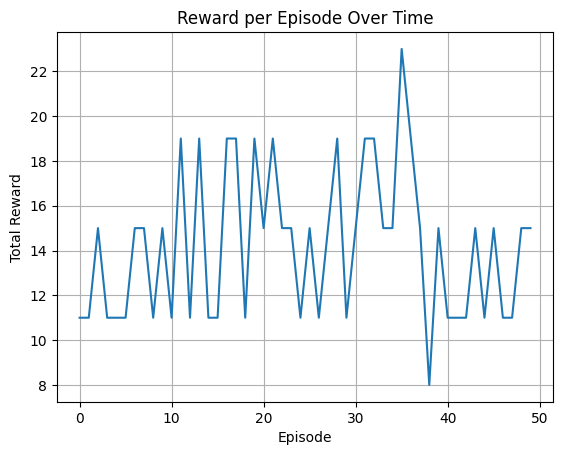

In [ ]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward per Episode Over Time")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Episode": np.arange(1, len(rewards) + 1),
    "Reward": rewards
})

df.head(), df.tail()

(   Episode  Reward
 0        1      11
 1        2      11
 2        3      15
 3        4      11
 4        5      11,
     Episode  Reward
 45       46      15
 46       47      11
 47       48      11
 48       49      15
 49       50      15)

In [ ]:
print("Average Reward:", np.mean(rewards))
print("Highest Reward:", np.max(rewards))
print("Lowest Reward:", np.min(rewards))
print("Standard Deviation:", np.std(rewards))

Average Reward: 14.22
Highest Reward: 23
Lowest Reward: 8
Standard Deviation: 3.3543404716873924


In [ ]:
print("MDP Transition Model")
print("--------------------")

for s in P:
    for a in P[s]:
        print(f"From {s} via {a} → {P[s][a]}")

MDP Transition Model
--------------------
From S0 via A → {'S1': 0.9, 'S0': 0.1}
From S0 via B → {'S1': 1.0}
From S1 via A → {'S2': 1.0}
From S1 via B → {'S0': 1.0}
From S2 via A → {'S2': 1.0}
From S2 via B → {'S2': 1.0}


##### **ACTIVITY 2**

In [ ]:
def run_multiple_episodes(n=50, max_steps=10):
    episode_rewards = []

    for _ in range(n):
        total_reward, _ = run_episode(max_steps=max_steps, verbose=False)
        episode_rewards.append(total_reward)

    return episode_rewards

rewards = run_multiple_episodes(n=50, max_steps=10)
print("Rewards per Episode:", rewards)
print("Average Reward:", np.mean(rewards))

Rewards per Episode: [11, 23, 19, 15, 15, 11, 19, 19, 15, 19, 19, 23, 23, 11, 11, 15, 11, 15, 19, 19, 15, 23, 11, 15, 11, 11, 15, 15, 11, 11, 11, 11, 15, 15, 11, 11, 15, 15, 15, 11, 15, 11, 13, 15, 15, 23, 19, 15, 15, 11]
Average Reward: 15.04


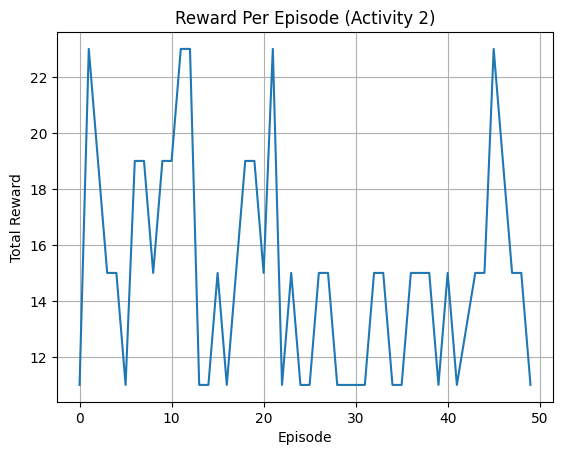

In [ ]:
import matplotlib.pyplot as plt

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward Per Episode (Activity 2)")
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

df_rewards = pd.DataFrame({
    "Episode": np.arange(1, len(rewards) + 1),
    "Reward": rewards
})

df_rewards.head(), df_rewards.tail()

(   Episode  Reward
 0        1      11
 1        2      23
 2        3      19
 3        4      15
 4        5      15,
     Episode  Reward
 45       46      23
 46       47      19
 47       48      15
 48       49      15
 49       50      11)

In [ ]:
print("Average Reward:", np.mean(rewards))
print("Highest Reward:", np.max(rewards))
print("Lowest Reward:", np.min(rewards))
print("Reward Standard Deviation:", np.std(rewards))

Average Reward: 15.04
Highest Reward: 23
Lowest Reward: 11
Reward Standard Deviation: 3.805049276947672


In [ ]:
print("MDP Transition Model for Activity 2")
print("-----------------------------------")
for state in P:
    for action in P[state]:
        print(f"{state} + {action} → {P[state][action]}")

MDP Transition Model for Activity 2
-----------------------------------
S0 + A → {'S1': 0.9, 'S0': 0.1}
S0 + B → {'S1': 1.0}
S1 + A → {'S2': 1.0}
S1 + B → {'S0': 1.0}
S2 + A → {'S2': 1.0}
S2 + B → {'S2': 1.0}


REFLECTION:

1. **How did the randomness in the transition probabilities affect the agent’s ability to reach the goal state, and what does this tell you about real-world decision-making under uncertainty?**

    Napansin ko na malaking epekto talaga yung randomness sa paggalaw ng agent. Kahit na may “best” action sa isang state, hindi pa rin siya palaging mapupunta sa goal state dahil may chance na madisgrasya ang transition. Minsan expected ko na papunta na siya sa S1, pero bumabalik pala siya sa S0. Parang real life din—kahit gaano ka ka-prepared o ka-sigurado sa plano mo, may mga bagay na hindi mo kontrolado. Kaya kailangan marunong ka mag-adjust at tanggapin na may uncertainty talaga sa mga desisyon.


2. **After running multiple episodes, what patterns did you observe in the rewards collected, and how did these patterns help you understand the effectiveness of the actions chosen by the agent?**

    Sa multiple episodes naman, mas naging obvious ang pattern ng rewards. Kapag nakakatulong ang randomness at napupunta siya sa S2 nang madalas, mataas ang reward. Pero kapag bad trip ang swerte at paulit-ulit siyang bumabalik sa S0, bagsak ang total reward. Nakita ko rin na kahit random ang actions, may tendency pa rin na mas maganda ang outcome kapag nag-A sa S1 dahil diretso siya sa S2. Dahil dito, mas naging malinaw sa akin kung bakit mahalaga ang tamang choice at kung paano naaapektuhan ng probability ang long-term rewards. Hindi lang pala ito basta-basta simulation—may aral sa strategy at timing.

3. **If you were to redesign the MDP, by changing rewards, adding states, or modifying transitions, what improvements or strategic behaviors would you expect from the agent, and why?**

    Kung ako ang magre-redesign ng MDP, gagawin ko itong mas “rewarding” sa good choices at mas “punishing” sa bad ones. For example, pwede kong dagdagan ng penalty kapag bumabalik sa S0 para mas ma-encourage ang agent na iwasan ang risky transitions. Pwede rin akong magdagdag ng extra states para mas interesting ang path papunta sa goal—parang may mini-challenges bago makarating sa S2. Ang inaasahan ko, mas magiging strategic ang agent, mas consistent ang pag-abot niya sa goal, at mas makikita mahalaga ang pag-optimize ng actions kaysa umasa lang sa random choices.